In [6]:
%load_ext autoreload
%autoreload 2
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))
import warnings
warnings.filterwarnings("ignore")

import os
import pandas as pd

ddir = 'data/'
# df = pd.read_csv(os.path.join(ddir,'chembl_augmented_valid.csv'),usecols=['SMILES'])
# df.columns = ['smiles']

# from rdkit_utils import *

# df_med = df[df.smiles.str.len() > 10]
# df_med = df_med[df.smiles.str.len() < 25]
# df_med['smiles'] = df_med.smiles.apply(lambda x: get_cansmiles(x))
# df_med.drop_duplicates(inplace=True)
# print(len(df_med))

# df_samp = df_med.sample(10000, replace=False)
# df_samp.to_csv('data/df_samp_10to25_10000.csv',index=False)

df = pd.read_csv(os.path.join(ddir,'df_samp_10to25_10000.csv'))
df.head(5)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


,smiles
0,COc1cccc(CSc2nnc(N)s2)c1
1,Cc1cc(C2CCC2)nc2ccccc12
2,CC(C)C(=O)C=Cc1ccccc1O
3,Cc1cc(C)cc(OCCCC(=O)O)c1
4,Nc1ncc(S(=O)c2cccs2)s1


In [8]:
from rdkit.Chem import PandasTools
def displaydf(df):
    return HTML(df.to_html(notebook=True))

PandasTools.AddMoleculeColumnToFrame(df,'smiles','mol',includeFingerprints=False)

In [9]:
from data_utils import *
atom_to_cnt = get_atom_cnts(df.smiles)
atom_to_cnt

{'C': 95281,
 'O': 14081,
 'S': 2993,
 'N': 17558,
 'Br': 479,
 'Cl': 1090,
 'F': 754,
 'P': 225,
 'I': 118,
 'B': 0}

In [14]:
from tqdm import tqdm

from rdkit import RDLogger  
RDLogger.DisableLog('rdApp.*')

from rdkit_utils import *
from graph_augs import *

source_to_augs = {}

for _,row in tqdm(df.iterrows(), total=len(df)):  
    
    source_to_augs[row['smiles']] = []
    mol = row['mol']


    idc = [i for i in range(0,(mol.GetNumAtoms()))]
    random.shuffle(idc)
    
    goods = 0 
    
    for i in idc:
        
        if goods==10:
            break
            
        atom_type = get_weighted_random_atom(atom_to_cnt)
        
        try: 
            mol_aug = add_atom_to_mol(mol, atom_type, i)
            if mol_aug.GetNumAtoms()==0:
                continue
            else:
                sm = Chem.MolToSmiles(mol_aug)
                goods+=1
                source_to_augs[row['smiles']].append(sm)
        except Exception as e:
            continue

100%|██████████| 10000/10000 [01:51<00:00, 89.55it/s]


In [15]:
for k,v in source_to_augs.items():
    print(k,len(v))

COc1cccc(CSc2nnc(N)s2)c1 9
Cc1cc(C2CCC2)nc2ccccc12 10
CC(C)C(=O)C=Cc1ccccc1O 10
Cc1cc(C)cc(OCCCC(=O)O)c1 9
Nc1ncc(S(=O)c2cccs2)s1 8
CCCCCCCCN(CC#N)c1ccccc1 10
CN(C)CCc1ccccc1Br 8
CC1CCc2c1ssc2=S 7
CCCCCCCC(=O)O 8
c1ccc(C2=NCCCCN2)cc1 10
CCn1cc2c([N+](=O)[O-])cccc2n1 6
COc1cc(C(O)C(C)O)ccc1O 10
Clc1nssc1=Nc1nncs1 4
CCC(C)n1cc(C(=O)CF)cn1 7
O=C(C1CCC1)N1CC2CC(C1)N2 10
Cc1csc[n+]1CC(=O)[O-] 5
C#CCNC(=O)C=Cc1ccc(C)cc1 10
CCNC(C)C(=O)c1cccc(Cl)c1 9
CCOOC1(OC)CCCCCCCCCCC1 10
CCCCCCCc1cc(O)cc(=O)o1 10
CCCCSCc1cc(=O)c(O)co1 9
Brc1ccc(C=Nn2cnnc2)cc1 7
Cc1nnc(NN=Cc2ccco2)n1N 7
CCCCc1ccc(O)c(O)c1O 9
C=C(O)C(=O)OC 3
Cc1csc(NN=Cc2ccccc2)n1 10
Oc1ccc2c(c1)C1(CCC2)CCNC1 10
C(=Cc1ccccc1)CN1CCNCC1 10
NCCNC(=O)c1ccccc1 9
O=C(NCc1ccccn1)NC1CCCCC1 10
CCCC=Cc1ccc2ccccc2n1 10
O=[N+]([O-])c1ncc[nH]1 0
O=C1C=C2CCCC(Br)=C2O1 4
CC(C)CC=C(C=O)c1ccccc1 10
CC1CCN(Cc2ccccc2)CC1 10
CC1C(=O)NC(=O)C1c1ccccc1 9
COc1ccc(C=CC(=O)NCCO)cc1 10
O=C(Cc1ccccc1)Nc1ccsc1CO 10
COc1ccc(CCc2ccccc2)cc1O 10
CC1OC2(CCN(C)CC2)CC1=NO 9


O=c1ccc(-c2ccccc2)co1 8
Cc1nssc1=S 4
C=Cc1ccc(OC(C)=O)cc1 7
O=C(O)c1sc2ccccc2c1Cl 6
CCNC(=O)Cn1cccc(O)c1=O 8
O=C(O)c1ccc(C(=O)O)cc1 6
CCOCN1COCN(C)C1=O 6
CCNC(=O)c1c(C)nc2ccccn12 8
CC(C)N1CCC2(CCCNC2)C1=O 10
CCC1CCC(CN)(CC(=O)O)CC1 10
C1=C(c2cccnc2)CCNC1 9
NN1C(=O)Cc2ccccc2C1=O 6
O=C1NCCC(O)C1O 7
NCP(=O)(O)CO 6
CCN(CC)NC(=S)Nc1ccccc1 10
Nc1ccc([N+](=O)[O-])cc1N 5
CSc1nncc2cnc(C)n12 5
CNCc1ccc(C(F)(F)F)cc1 7
CN1CCCCC1CCC1(C)SCCCS1 10
NNC(=O)c1ccccc1S 7
CCCc1c[nH]c2ccc(F)cc12 0
C1=C(c2cccs2)C2CCC1N2 10
C#CCCCCCCCCC(=O)NCCCC 10
O=S1c2ccccc2SN1C1CC1 9
O=C(CCl)c1ccc(Br)s1 4
CC(C)(C)CI 5
CN(C)CCOc1ccc(Cl)nc1 7
Nc1ccc(C(=O)O)c(C(=O)O)c1 6
CNC(=O)C(CCCCNC(C)=O)NC 10
CCCCCCCCCCCCCCCCCCCl 10
CC(O)CNc1cnccn1 8
CCc1nc(N)ccc1C(=O)O 6
C=Cc1c(CO)cnc(CO)c1O 8
CCC(C)C(=O)NC1CCN2CCCC12 10
OCCOCCNc1nc[nH]c2ncnc1-2 0
N#CC12CCCC3CC(CCC31)C2 10
NCCCCC(N)C(=O)N1CCOCC1 10
CCCC(=O)OCCC(C)CCC=C(C)C 10
Oc1ccc(Cl)cc1N=Nc1ccccc1 9
Cn1ccc(-c2ccc(Br)cc2)c1 8
N#CC(C#N)=Cc1cccc(O)c1 6
O=c1oc2ccccc2cc1-c1cccs1 9
Cc1[nH

Cn1ccnc1COc1ccc(CO)cc1 10
Brc1ccc(C2=CN3CCC2CC3)o1 8
CCCN(CC)CCc1ccc(O)c(O)c1 10
Nc1n[nH]c(SCc2ccccc2)n1 0
CCCCOC(=S)C=Cc1ccccc1 10
CC(=O)OCCCCN(C)C 7
CC(N)(CCCN)OP(O)O 9
CCCCCCC=CCCCC(=O)O 10
Cn1ccc(=O)c(C(N)=O)c1 5
CC1=Nc2ccc(C)cc2N=C(C)C1 7
COc1ccc(Cn2cncc2CCCO)cc1 10
CCC(C(=N)NO)N1CCCC1=O 9
CCNC(=S)Nc1ccc(OCC)cc1 10
OC(CCl)CNc1ccc(Cl)cc1 9
Cn1nc(CCO)ccc1=O 6
NCC(=O)NCC(=O)NCCC(=O)O 8
O=C1NC(O)c2ccccc2O1 7
O=C(O)c1cc2ccccc2n1O 7
Cc1ccc(NC(=O)C(C)N)cc1 9
O=C1c2ccccc2CSc2sccc21 9
Oc1ccc(C=NN2CCCCC2)c(O)c1 10
CC(=O)N(C)CC#CCn1cncc1C 7
CC(=NOCCC(=O)O)C1CC1 7
CCCCCCCC1(C)NC(=O)NC1=O 10
Cc1cc(Cl)ccc1NC(=O)C=NO 7
N#CC1Sc2ccccc2-n2cccc21 9
COc1ccc2c(c1)C1CCC2C1N 10
CCCNCc1ccc(Cl)c(Cl)c1 8
Cc1ccc(-c2n[nH]c(=O)[nH]2)cc1 5
OC(c1ccccc1)c1ccc(Cl)cc1 10
O=c1ccc(-c2ccccc2)cn1O 9
CC(C)OCC(O)CNC(C)(C)C 10
Cc1cccc(NC(=S)NCCO)c1C 10
CNC(=NC#N)NCCCCCn1ccnc1C 10
COc1cccc2cc(C)cc(O)c12 8
CSc1ccc2[nH]c(=O)cc(C)c2c1 0
CC(N)Cn1ncc2ccc3occc3c21 9
Cc1cnc(NC(=O)C2CCCO2)s1 8
C=CCNC(=O)CCCc1ccccc1 10
CN=CNc1cc(C

O=C(O)CNCCP(=O)(O)O 8
NCC(CC(=O)O)c1ccsc1 9
CCCCN(CCO)CCC(=O)c1ccco1 10
Cc1ccccc1C(N)c1ccncc1 10
COCCNC(=S)NCc1cccs1 10
CNc1ccc(Cl)cc1S(N)(=O)=O 6
Fc1cccc(CCCN2CCCC2)c1 10
c1csc(-c2cnc3n2CCCC3)c1 9
O=C1NCCN(c2cccnc2)N1 8
CCC(C)CCCC(C)(C)O 10
CC(=O)NC1CNCC(O)C(O)C1O 10
CCCCCCCCCP(=O)(O)OCC 10
CNCC(=O)c1c[nH]c2ccccc12 0
CCCCCCCCC(=O)NCc1ccncc1 10
COC(=O)C(N)CS 5
CC(N)C(=S)N1CCCC1 8
CCOCC(=O)N(CC)Cc1ccccc1 10
c1ccc(CCCc2c[nH]cn2)nc1 0
NN=c1[nH]c(F)c(F)c(N)c1F 0
CCCCOc1nonc1S(N)(=O)=O 5
Cc1ccc([N-][N+]#N)cc1 5
Cc1nonc1-c1nc2ccccc2s1 6
CN1CC=C(C=Cc2ccccc2)CC1 10
CCCCC(=O)NCCc1ccc(OC)cc1 10
O=c1ccc2c(ccc3ccccc32)o1 8
O=c1c2cccnc2nc2n1CCCCC2 8
O=c1ccccc2cccc(O)c12 8
OC1(c2ccc(F)cc2)CCNC1 9
O=c1[nH]ccc(-c2ccccc2)c1O 0
Oc1cccc2[nH]ccc12 0
CN1CCCC1COc1cccnc1Br 9
CCCCOc1ccc2nncn2n1 7
Nc1cccc2nc3ccccc3cc12 9
Cc1cc(C)nc(NCCC(=O)O)n1 7
Oc1ccc2ccoc2c1 6
OCC(O)CNC(=S)NC1CCCCC1 10
C#CC(N)CCC(=O)O 6
CC1C2CC(CC(=O)N2)C1(C)C 9
O=C(c1ccccc1F)N1CCOCC1 8
CC(C)(C)c1nnc(=O)n(N)c1O 5
N#CCSc1nnc(N)s1 4
Cn1cccc1C

CCC(=O)NCCc1cc(OC)ccc1OC 10
COCCCn1ccc(NC2CCSCC2)n1 10
O=C(O)C(CS)Cc1ccc(F)cc1 9
Nc1cnc(Br)cc1Br 3
CCC(C#N)NC(=O)c1sccc1OC 8
OC(Cc1ccccc1)C(F)(F)F 8
CC(C)=CCOC(=O)c1ccccc1 9
Cc1nc(=S)[nH]c(O)c1CCCO 0
Cc1nc2ccc(C(=O)O)cc2nc1C 6
S=c1[nH]nc(NCCCN2CCOCC2)s1 0
CCN1CCC=C(c2nnn(CC)n2)C1 8
CC1N=C(c2ccccc2)OC1=O 7
NCCCCOc1ccccc1Cc1ccccc1 10
NCC1CCCc2ccccc21 10
Fc1ccc(-c2n[nH]c(=S)o2)cc1 0
Cc1ccc2nc3c(nc2c1C)CCCC3 8
CS(=O)c1ccc2c(c1)CNCC2 9
CC=CCC1COCCC(N)=N1 9
CCCN1CCc2cccc(OC)c2CC1 10
C(CNC1CCNCC1)CNC1CCNCC1 10
O=C(CCC1CCCCC1)NCc1cccs1 10
CCCc1cncc(C2CCCN2C)c1 10
CCCCCCCCCCCCP(=O)(F)OC 10
CC1OC(c2ccc(Cl)cc2)OCC1N 10
CN1CCOc2cc(C=O)ccc21 7
O=C1C(=O)c2ccoc2-c2ccccc21 6
N=c1ncn2c3c1ncn3CC=CC2 7
CN1CCCCC1c1cncc(Cl)n1 8
CC(F)C(N)CCC(=O)O 7
O=c1[nH]c(Cc2ccccc2)ncc1O 0
Cc1cc(=S)[nH]c2c(C)cccc12 0
CC(=O)Nc1ccc(O)cc1 7
CCCc1nc(N)sc1C(=O)OCC 7
CN1C(C)(C)C=CCC1(C)C 8
O=C1C=Cc2c(Cl)sc(Cl)c21 3
CCC(CO)N1Cc2ccccc2C1=O 10
COc1ccc(NC(C)=O)cc1C 7
C(#Cc1ccccc1)CN1CCCCC1 10
N#CC1CNC(N)NC1N 8
CCCc1cc(O)cc(=O)o1 6

In [22]:
no_augs = [k for k,v in source_to_augs.items() if len(v)==0]
len(no_augs)

838

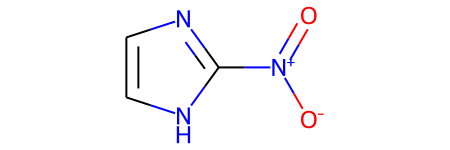

In [19]:
Chem.MolFromSmiles('O=[N+]([O-])c1ncc[nH]1')

In [16]:
import multiprocessing

multiprocessing.cpu_count()

12